In [5]:
import os
print(os.listdir('/kaggle/input/datasets'))

['rashikrahmanpritom']


TensorFlow version: 2.19.0

--- Loading Datasets ---
Found 1322 files belonging to 3 classes.


I0000 00:00:1780228190.334126      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780228190.340186      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 60 files belonging to 3 classes.
Found 150 files belonging to 3 classes.

Detected Class Labels Successfully: ['Healthy', 'Powdery', 'Rust']


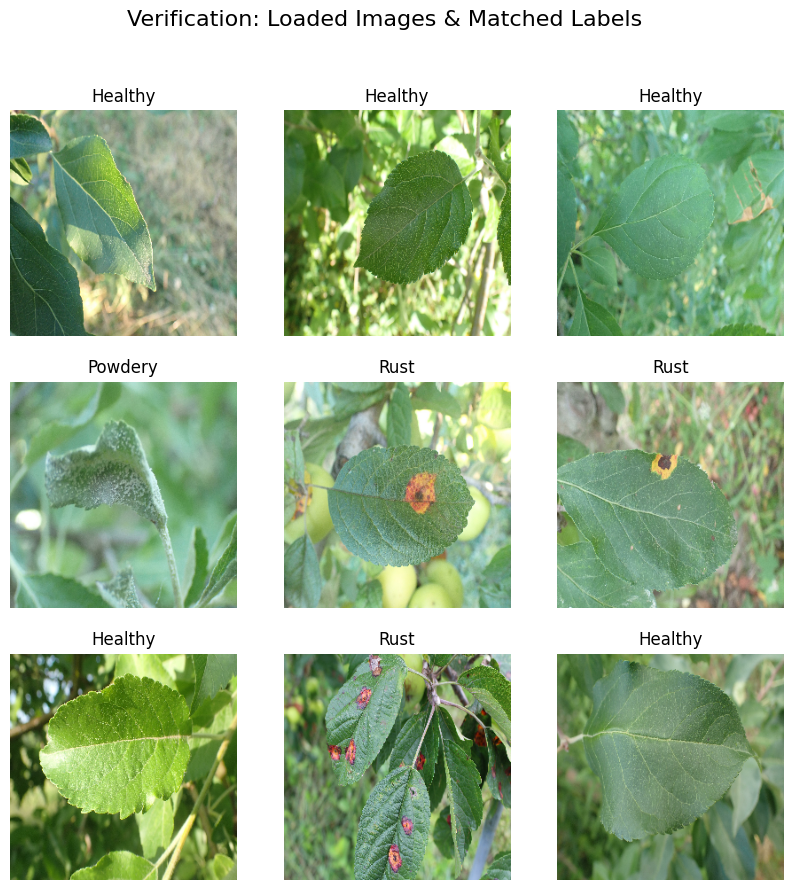

In [6]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Clear out background CUDA warning clutter from your output window
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

print("TensorFlow version:", tf.__version__)

# 2. Define the absolute, correct paths discovered on your Kaggle server drive
ROOT_PATH = "/kaggle/input/datasets/rashikrahmanpritom/plant-disease-recognition-dataset"
TRAIN_DIR = f"{ROOT_PATH}/Train/Train"
VAL_DIR = f"{ROOT_PATH}/Validation/Validation"
TEST_DIR = f"{ROOT_PATH}/Test/Test"

print("\n--- Loading Datasets ---")

# 3. Load the Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=(256, 256), batch_size=32, shuffle=True
)

# 4. Load the Validation Dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=(256, 256), batch_size=32, shuffle=False
)

# 5. Load the Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=(256, 256), batch_size=32, shuffle=False
)

# 6. Extract and print the detected class names to confirm success
class_names = train_ds.class_names
print("\nDetected Class Labels Successfully:", class_names)

# 7. VISUALIZE: Display a 3x3 grid of your leaves to verify everything looks right
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Verification: Loaded Images & Matched Labels", fontsize=16)
plt.show()

In [7]:
import numpy as np


# 1. Create a function that can get counts for any dataset
def check_dataset_counts(dataset, dataset_name):
    print(f"\n--- Class Wise Image Counts ({dataset_name} Data) ---")

    all_labels = []
    # Collect all labels from batches into a list
    for images, labels in dataset:
        all_labels.extend(labels.numpy())

    # Use NumPy to count
    unique_labels, counts = np.unique(all_labels, return_counts=True)

    # Print on screen
    for label_idx, count in zip(unique_labels, counts):
        class_name = class_names[label_idx]
        print(f"-> {class_name}: {count} images")

    print(f"Total {dataset_name} Images: {sum(counts)}")
    print("-" * 40)


# 2. Send our three datasets to this function one by one
check_dataset_counts(train_ds, "Training")
check_dataset_counts(val_ds, "Validation")
check_dataset_counts(test_ds, "Testing")


--- Class Wise Image Counts (Training Data) ---
-> Healthy: 458 images
-> Powdery: 430 images
-> Rust: 434 images
Total Training Images: 1322
----------------------------------------

--- Class Wise Image Counts (Validation Data) ---
-> Healthy: 20 images
-> Powdery: 20 images
-> Rust: 20 images
Total Validation Images: 60
----------------------------------------

--- Class Wise Image Counts (Testing Data) ---
-> Healthy: 50 images
-> Powdery: 50 images
-> Rust: 50 images
Total Testing Images: 150
----------------------------------------


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Image parameters used earlier during data loading
IMAGE_SIZE = 256
CHANNELS = 3

print("--- Data Augmentation & CNN Model Architecture is Getting Ready ---")

# 2. DATA AUGMENTATION LAYER (As per your Pipeline Diagram)
# This layer will dynamically transform images during each epoch of training
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal_and_vertical", input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
        ),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
    ]
)

# 3. MODEL BUILDING (Convolutional Neural Network)
model = models.Sequential(
    [
        # Apply Augmentation first (To solve the data scarcity problem)
        data_augmentation,
        # DATA CLEANING & PREPROCESSING: Scale pixels from 0-255 down to between 0-1
        layers.Rescaling(1.0 / 255),
        # Convolution Layer 1 & Pooling: To capture edges and curves
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Convolution Layer 2 & Pooling: To understand textures and shapes
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Convolution Layer 3 & Pooling: For complex leaf patterns
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Convolution Layer 4 & Pooling: For deep disease features
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Flatten: Convert 2D image data into a 1D single vector
        layers.Flatten(),
        # Dense Layer: The model's brain that will process the features
        layers.Dense(64, activation="relu"),
        # Output Layer: 3 units because we have 3 classes (Healthy, Powdery, Rust)
        # Softmax will give us the final answer as a percentage (%)
        layers.Dense(3, activation="softmax"),
    ]
)

# 4. Compile the model structure and set the rules
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

# Print the summary to see the complete model structure
model.summary()

--- Data Augmentation & CNN Model Architecture is Getting Ready ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,323 (3.42 MB)

 Trainable params: 896,323 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Checkpoint — BEST model auto-save
checkpoint = ModelCheckpoint(
    '/kaggle/working/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# 2. Early Stop
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("\n--- Model Training is Starting ---")

# 3. Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint, early_stop]
)

print("Training Complete!")

# 4. Final backup 
model.save('/kaggle/working/plant_disease_final.keras')

# 5. Load BEST model (which checkpoint saved )
best_model = tf.keras.models.load_model('/kaggle/working/best_model.keras')
print("Best model loaded!")


--- Model Training is Starting ---
Epoch 1/50


I0000 00:00:1780228227.815501     220 cuda_dnn.cc:529] Loaded cuDNN version 91002


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.4016 - loss: 1.0838
Epoch 1: val_accuracy improved from None to 0.53333, saving model to /kaggle/working/best_model.keras

Epoch 1: finished saving model to /kaggle/working/best_model.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 32s 589ms/step - accuracy: 0.4667 - loss: 1.0357 - val_accuracy: 0.5333 - val_loss: 1.1795
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.5647 - loss: 0.9011
Epoch 2: val_accuracy improved from 0.53333 to 0.65000, saving model to /kaggle/working/best_model.keras

Epoch 2: finished saving model to /kaggle/working/best_model.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 556ms/step - accuracy: 0.6225 - loss: 0.7812 - val_accuracy: 0.6500 - val_loss: 0.5690
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.7163 - loss: 0.5955
Epoch 3: val_accuracy improved from 0.65000 to 0.83333, saving model to /kaggle/working/best_model.keras

Epoch 3: finished saving model to /kaggle/working/best_model.keras
4

In [10]:
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,688,971 (10.26 MB)

 Trainable params: 896,323 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,792,648 (6.84 MB)

In [11]:
loss, accuracy = best_model.evaluate(val_ds)
print(f"Loaded Model Accuracy: {accuracy*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 568ms/step - accuracy: 0.9500 - loss: 0.1541
Loaded Model Accuracy: 95.00%


In [12]:
import numpy as np
from tensorflow.keras.preprocessing import image

CLASS_NAMES = class_names 
img_path = '/kaggle/input/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/Test/Test/Powdery/81c36e378473c93e.jpg' 

img = image.load_img(img_path, target_size=(256, 256))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) 

# Prediction
predictions = best_model.predict(img_array)

predicted_class = CLASS_NAMES[np.argmax(predictions)]
print(f"Result: {predicted_class}")
print(f"Confidence: {np.max(predictions)*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
Result: Powdery
Confidence: 99.78%
